In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input # Thêm Input vào đây
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/data đồ ăn/Train"

# Kích thước ảnh và kích thước lô
img_width, img_height = 128, 128
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2 # Tách 20% dữ liệu cho tập xác thực
)

In [11]:
" tải dữ liệu huấn luyện"

' tải dữ liệu huấn luyện'

In [12]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='training' # Chỉ định đây là tập huấn luyện
)

# Tải dữ liệu xác thực
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='validation' # Chỉ định đây là tập xác thực
)

Found 1152 images belonging to 8 classes.
Found 284 images belonging to 8 classes.


In [13]:
"xây dựng mô hình"

'xây dựng mô hình'

In [14]:

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Input(shape=(img_width, img_height, 3)), # Sử dụng lớp Input rõ ràng
    Conv2D(32, (3,3), activation="relu"), # Loại bỏ input_shape ở đây
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(8, activation="softmax")
])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,672 (12.61 MB)

 Trainable params: 3,305,672 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 586s 16s/step - accuracy: 0.1623 - loss: 2.0898 - val_accuracy: 0.2324 - val_loss: 1.9573
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 709ms/step - accuracy: 0.2188 - loss: 1.9525 - val_accuracy: 0.2923 - val_loss: 1.8189
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 693ms/step - accuracy: 0.2613 - loss: 1.9036 - val_accuracy: 0.3275 - val_loss: 1.7541
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 694ms/step - accuracy: 0.2856 - loss: 1.8452 - val_accuracy: 0.3275 - val_loss: 1.7411
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 710ms/step - accuracy: 0.3385 - loss: 1.7827 - val_accuracy: 0.3979 - val_loss: 1.6399
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 713ms/step - accuracy: 0.3438 - loss: 1.7421 - val_accuracy: 0.3944 - val_loss: 1.6721
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 694ms/step - accuracy: 0.3446 - loss: 1.7001 - val_accuracy: 0.4613 - val_loss: 1.5483
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 685ms/step - accuracy: 0.3464 - loss: 1.7658 - val_accur

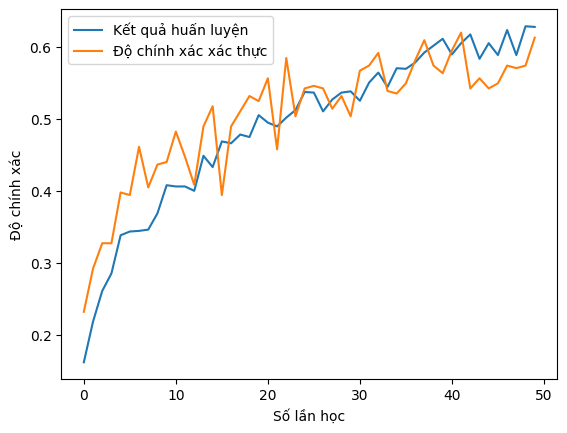

In [15]:
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 50
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator) # Thêm validation_data

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực") # Bỏ comment dòng này
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [16]:
model.save('nhận diện đồ ăn.h5')

In [17]:
from google.colab import files
files.download('nhận diện đồ ăn.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

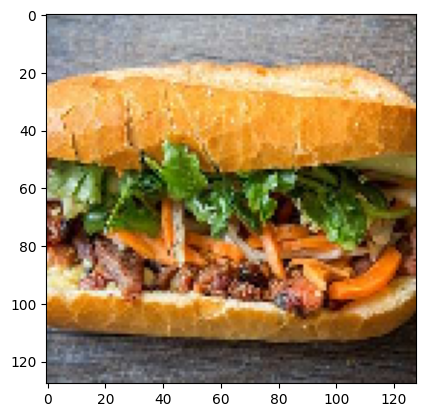

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
 đồ ăn tiên đoán: Bánh mì


In [18]:
from keras.utils import load_img
import numpy as np
from keras.models import load_model # Import load_model

# Load the saved model
saved_model = load_model('nhận diện đồ ăn.h5') # Load your saved model

path = "/content/drive/MyDrive/data đồ ăn/Test/2.jpg"

# Tải và tiền xử lý ảnh kiểm tra
img = load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)

# Tiên đoán loại
prediction = np.argmax(saved_model.predict(img)) # Use the loaded model for prediction

# Ánh xạ loại tới tên người (ensure train_generator is available or re-create class_indices)
# If train_generator is not available, you would need to define class_indices manually
# For example: class_labels = {0: 'class1', 1: 'class2', ...}
# Assuming train_generator is still in scope from previous execution
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f" đồ ăn tiên đoán: {person_name}")